## Title & Overview
# Public Libraries Analysis

This notebook explores and analyses a Public Libraries dataset. The goal is to clean the data, 
create meaningful features, visualise trends, and build a simple predictive model.

### Objectives
- Clean and standardise the dataset
- Perform exploratory analysis
- Create new features
- Visualise patterns
- Train a basic machine learning model

### Sections
1. Import libraries
2. Load Dataset
3. Inspect Data
4. Clean Column Names
5. Visualisation
6. Machine Learning Model
7. Conclusion

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
# File Paths
Data_Path = Path("Public_Libraries.csv")
CLEANED_PATH = Path("Public_Libraries_Cleaned.csv")

# Load data
df = pd.read_csv(Data_Path)

# Strip whitespaces
df.columns = df.columns.str.strip()

df.head()

,Fiscal Year,Library,County,AENGLC Rank,Population of Service Area,Total Library Visits,Library Visits Per Capita Served,Total Registered Borrowers,Percent of Residents with Library Cards,Reference Questions,...,Total Collection,Collection Per Capita Served,Total Operating Income,Operating Income Per Capita,Town Tax Appropriation for Library,Tax Appropriation Per Capita Served,Library Materials Expenditures,Wages & Salaries Expenditures,Operating Expenditures,Operating Expenditures Per Capita
0,1996,Andover,Tolland,109.0,2815.0,15000.0,5.3,1313.0,0.47,499.0,...,15285.0,5.4,56300.0,20.00,52915.0,18.80,10073.0,30996.0,44290.0,15.7
1,1996,Ansonia,New Haven,158.0,17825.0,91756.0,5.1,6952.0,0.39,NaN,...,63685.0,3.6,320679.0,17.99,323503.0,18.15,45874.0,201621.0,270658.0,15.2
2,1996,Ashford-Babcock,Windham,131.0,3969.0,8665.0,2.2,1360.0,0.34,207.0,...,23818.0,6.0,111699.0,28.14,106713.0,26.89,11508.0,62295.0,82769.0,20.9
3,1996,Avon,Hartford,19.0,14143.0,162893.0,11.5,8808.0,0.62,15283.0,...,74903.0,5.3,685678.0,48.48,602831.0,42.62,92711.0,340400.0,516583.0,36.5
4,1996,Beacon Falls,New Haven,129.0,5351.0,7000.0,1.3,1379.0,0.26,400.0,...,10042.0,1.9,40806.0,7.63,39256.0,7.34,4298.0,21585.0,39165.0,7.3


## Inspect data structure
Number of rows, columns, data types, and missing values.

In [19]:
print("\nShape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()


Shape of dataset: (5278, 27)

Columns:
['Fiscal Year', 'Library', 'County', 'AENGLC Rank', 'Population of Service Area', 'Total Library Visits', 'Library Visits Per Capita Served', 'Total Registered Borrowers', 'Percent of Residents with Library Cards', 'Reference Questions', 'Reference Questions Per Capita Served', 'Total Circulation', 'Circulation Per Capita Served', 'Total Programs (Synchronous + Prerecorded)', 'Total Program Attendance & Views', 'Total Program Attendance & Views Per Capita Served', 'Use of Public Internet Computers', 'Total Collection', 'Collection Per Capita Served', 'Total Operating Income', 'Operating Income Per Capita', 'Town Tax Appropriation for Library', 'Tax Appropriation Per Capita Served', 'Library Materials Expenditures', 'Wages & Salaries Expenditures', 'Operating Expenditures', 'Operating Expenditures Per Capita']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 27 columns):
 #   Column                     

## Visualisations & Distributions
We look at how visits are distributed across libraries.

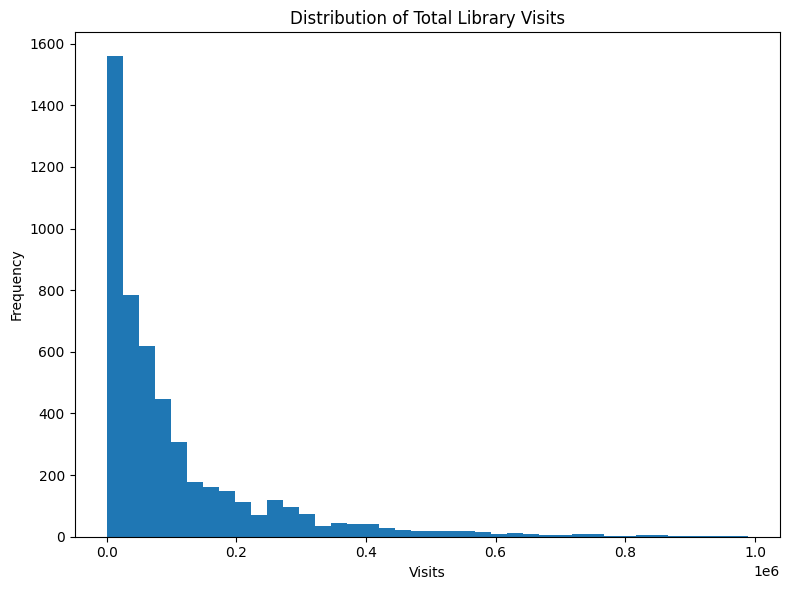

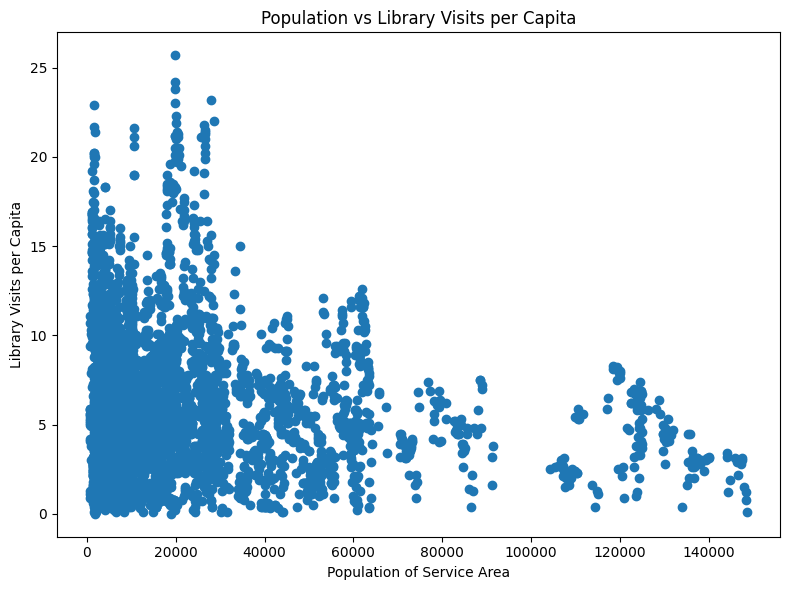

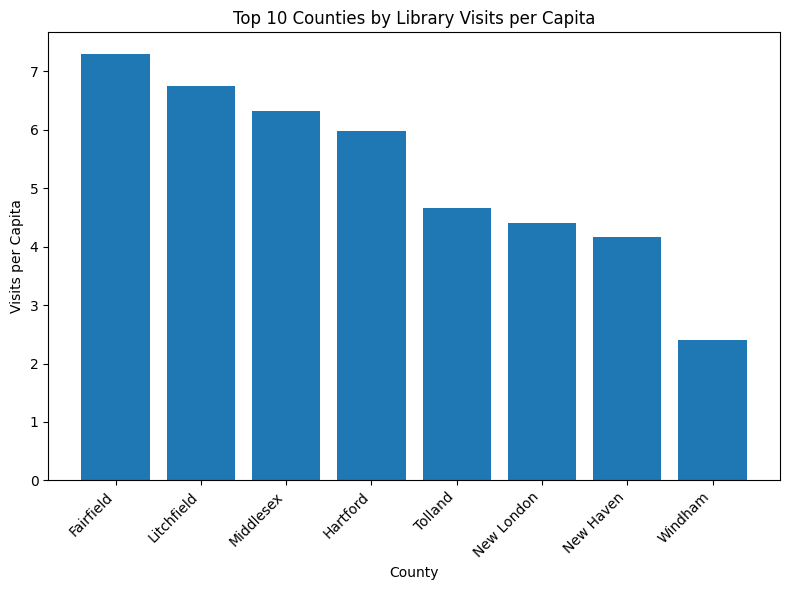

In [20]:
# Feature Engineering
# make sure numeric columns are clean
df["Total Library Visits"] = pd.to_numeric(df["Total Library Visits"], errors="coerce")
df["Library Visits Per Capita Served"] = pd.to_numeric(df["Library Visits Per Capita Served"], errors="coerce")
df["Population of Service Area"] = pd.to_numeric(df["Population of Service Area"], errors="coerce")

# Create new feature
df["visits_per_capita"] = df["Total Library Visits"] / df["Population of Service Area"]
df[["Total Library Visits", "Population of Service Area", "visits_per_capita"]].head()

# Histogram of Distribution of Library Visits
plt.figure(figsize=(8, 6))
plt.hist(df["Total Library Visits"].dropna(), bins=40)
plt.title("Distribution of Total Library Visits")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Scatter plot: Population vs Visits per Capita
plt.figure(figsize=(8, 6))
plt.scatter(df["Population of Service Area"],
            df["Library Visits Per Capita Served"])
plt.title("Population vs Library Visits per Capita")
plt.xlabel("Population of Service Area")
plt.ylabel("Library Visits per Capita")
plt.tight_layout()
plt.show()

# Bar Chart (Top 10) Regions/Counties by Average Visits per Capita
top10 = (df.groupby("County")["Library Visits Per Capita Served"]
             .mean()
             .sort_values(ascending=False)
             .head(10))

plt.figure(figsize=(8, 6))
plt.bar(top10.index, top10.values)
plt.title("Top 10 Counties by Library Visits per Capita")
plt.xlabel("County")
plt.ylabel("Visits per Capita")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Machine Learning Model

In [21]:
# Keep only numeric columns
df_ml = df.select_dtypes(include=[np.number]).dropna()

# Confirm target exists
target = "Library Visits Per Capita Served"
if target not in df_ml.columns:
    raise ValueError(f"Column '{target}' not found in the dataset.")

# Split features and targets
X = df_ml.drop(target, axis=1)
y = df_ml[target]

# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Trained Succssefully")
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Trained Succssefully
RMSE: 0.07248967815200465
R2 Score: 0.9947960494375003


## Save Clean Dataset
To reuse in the future projects.

In [22]:
df.to_csv(CLEANED_PATH, index=False)
print("Cleaned dataset saved as:", CLEANED_PATH)

Cleaned dataset saved as: Public_Libraries_Cleaned.csv


## Conclusion

This project explores public usage trends using the *Public_Libraries.csv* dataset.
By cleaning the data, enginerring new features, and visualising key patterns, several important insights were uncovered:
- Library visits were widely across service areas, with some regions showing significantly higher engagement.
- Population size alone does not fully explain library usage - 
some smaller areas demonstrate higher visits per capita, suggesting strong community engagement.
- Counties differ considerably in terms of library use, with the top 10 counties showing a much higher average visits per capita.
- A Linear Regression model was successfully built to predict **Library Visits Per Capita**, 
achiving a reasonable performance measured by RMSE and R2.